# Error propagation and confidence intervals for correlated data points 

You have the data file "data_cov.dat" which contains 10 pairs of measurements $(a_i, b_i)$. You consider reporting the mean and standard deviation on $a$ and $b$. Is this information sufficient to calculate a 99% confidence interval on $\bar{c} = \bar{a} + \bar{b}$? Explain why this is not sufficient and demonstrate it numerically.   

Bonus: Calculate a 99\% CI on $\bar{c}$. 

Tip: Instead of calculating the sample covariance manually, you can use `np.cov(a, b, ddof=1)`. 

## About correlation coefficients

Given two length-$N$ samples of data $\{x_i\}$ and $\{y_i\}$, Pearson's correlation coefficient is defined as

$$ r = \frac{\sum_{i=1}^N (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^N (x_i-\bar{x})^2}\sqrt{\sum_{i=1}^N (y_i-\bar{y})^2}} $$

where $-1\leq r\leq 1$, and $r=0$ for uncorrelated variables.

If the pairs $(x_i,y_i)$ are drawn from uncorrelated univariate Gaussian distributions, then the distribution of $r$ follows a Student's $t$ distribution with $k=N-2$ degrees of freedom and $t = r\sqrt{(N-2)/(1-r^2)}$ (so this is the normalised RV $r$ built based on t that follows a student ; this also means that the $stde(r) = \sqrt{\frac{1-r^2}{N-2}}$).

Because of this, a measured $r$ can be interpreted in terms of the significance with which we can reject the variables being correlated, e.g., if $N=10$ then the probability that a value of $r\geq 0.72$ arises just by chance noise fluctuations is $1\%$. 

The p-value is the probability for getting a value at least as large as the one observed. So a small p-value (conventionally smaller than 0.05) is used as an indication that the obtained value is not a statistical fluke. One may however not abuse of it / puts too much trust in it (but it is sometimes that only objective way we have to quantify a "visual" statement). 

The Pearson's coefficient can be calculated in python using `numpy.corrcoef()`.  There are two big problems with Pearson's coefficient though:
- It does not incorporate measurement uncertainties on the data.
- It is highly susceptible to outliers.

Alternative coefficients have been introduced, such as the Spearman's-r coefficient (less sensible to outliers but biased) and the Kendall's-$\tau$ coeffcient. 

See **Chapter 3** of of the book <a class="anchor" id="book"></a> *Statistics, data mining and Machine learning in astronomy* by Z. Ivezic et al. in Princeton Series in Modern Astronomy for a more exhaustive discussion of correlation coefficients (and alternatives to Pearson's $r$ correlation coefficients. 

Why $n-1$ as Bessel's correction for calculating the covariance $\sigma_{ab}$? See https://stats.stackexchange.com/questions/142456/why-shouldnt-the-denominator-of-the-covariance-estimator-be-n-2-rather-than-n-1/142472#142472 . 

Answer: 
- In the situation where a and b would be uncorrelated, this would not be completely sufficient as the authors would need to know the **number** of points used for the calculation (and be sure that the Bessel correction had been used for the calculation of the std). 
- In the situation where $a$ and $b$ are correlated, the reader would **also** need to have an estimate of the covariance between $a$ and $b$ or equivalently of the full covariance matrix $Cov(a,b)$. 

In [1]:
import numpy as np
import scipy.stats 
from matplotlib import pyplot as plt

In [2]:
# Generation of the data to be analysed
n_2d = scipy.stats.multivariate_normal(mean=[0.5, 0.], cov=[[2.5, 0.3], [0.3, 0.5]])
data_sample = n_2d.rvs(size=10, random_state=25)
np.savetxt("data_cov.dat", data_sample)

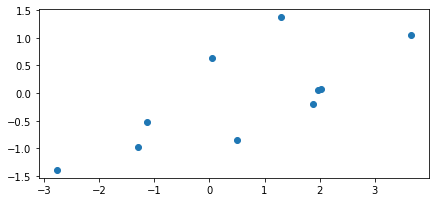

In [3]:
data_sample = np.loadtxt("data_cov.dat")
a, b = data_sample[:,0], data_sample[:,1]
f, ax = plt.subplots(figsize=(7,7))
ax.scatter(a, b)
ax.set_aspect('equal')

In [16]:
np.corrcoef(a, b)

array([[1.        , 0.72195253],
       [0.72195253, 1.        ]])

In [17]:
cov_mtx_ab

array([[3.73700531, 1.25525937],
       [1.25525937, 0.80895795]])

In [15]:
# To evaluate the correlation and have an estimate of the covariance
# we can use np.corrcoef() and np.cov() 
pearson_cor = np.corrcoef(a, b)
pearson_r = pearson_cor[0,1]  # the pearson coef. between a and b is along the non diag. element
cov_mtx_ab = np.cov(a, b, ddof=1)  # ddof = 1 not 2. A bit counter intuitive but this can be demonstrated
print('Covariance matrix \n', cov_mtx_ab)
Npts = len(a)
stde_r = np.sqrt((1-pearson_r**2) / (Npts-2) )
print('Pearson correlation coef. %.3f (stde(r) = %.3f)' %(pearson_r, stde_r))
# distribution of the pearson correlation coef. 
dist_pearson = scipy.stats.t(Npts - 2)   # t(N-2) 
t_test =  pearson_r * np.sqrt( (Npts-2) / (1-pearson_r**2) ) 

p_val = 1 - dist_pearson.cdf(t_test)
print('p-value (one-tailed) of Pearson r = %.3f'%p_val) 
# we may prefer a 2-tailed p-value ; a r = -0.722 would be an anti-correlation
# We can multiply the one-tailed by 2 because of the symmetry of the distribution
print('p-value (two-tailed) of Pearson r = %.3f'% (2. * p_val))   

# Now, we can do all this at once with scipy.stats.pearsonr()
scpy_pearson, scpy_p_val = scipy.stats.pearsonr(a, b)
print('Scipy calculation')
print('Pearson correlation coef. %.3f , and p-val = %.3f' %(scpy_pearson, scpy_p_val))
print('Scipy returns 2-tailed p-value which is TWICE the one-tailed p-val')

Covariance matrix 
 [[3.73700531 1.25525937]
 [1.25525937 0.80895795]]
Pearson correlation coef. 0.722 (stde(r) = 0.245)
p-value (one-tailed) of Pearson r = 0.009
p-value (two-tailed) of Pearson r = 0.018
Scipy calculation
Pearson correlation coef. 0.722 , and p-val = 0.018
Scipy returns 2-tailed p-value which is TWICE the one-tailed p-val


The large r and the associated p-value indicates that there is indeed a substantial correlation between a and b. 

In [6]:
# We can calculate the standard deviation and the sqrt(covariance) 
# based on the elements of the cov matrix
# Diagonal elements = variance ; non diagonal elements = covariance
std_a = np.sqrt(cov_mtx_ab[0, 0])  
std_b = np.sqrt(cov_mtx_ab[1, 1])
std_ab = cov_mtx_ab[0,1]
print('<a> = %.2f ; std_a = %.2f'%(a.mean(), std_a))
print('<b> = %.2f ; std_b = %.2f'%(b.mean(), std_b))
print('std_ab = %.2f'%std_ab)

<a> = 0.62 ; std_a = 1.93
<b> = -0.08 ; std_b = 0.90
std_ab = 1.26


Let's now show that giving the std is not enough to calculate a CI on c. 
Based on the error propagation formula, we know that the variance on c transofrms as: 

$$
\sigma^2_c =  \sigma^2_a + \sigma^2_b + 2 * \sigma_{ab}
$$

Providing only $\bar{a}$, $\bar{b}$ , $\sigma^2_a$, $\sigma^2_b$ means that we would drop the covariance ...    

Let's compare the variance on c to the variance derived from the error propagation formula without and with the covariance. 

In [7]:
# True variance on c
c = a + b 
var_c = np.var(c, ddof=1)
# Variance on c from error propagation ignoring the covariance 
var_c_no_cov = cov_mtx_ab[0, 0] + cov_mtx_ab[1, 1]
var_c_w_cov = cov_mtx_ab[0, 0] + cov_mtx_ab[1, 1] + 2 * cov_mtx_ab[1, 0]
print('True variance on c = %.3f '%var_c)
print('Variance on c from a, b ignoring the covariance: %.3f ' %var_c_no_cov)
print('Variance on c from a, b accounting for the covariance: %.3f ' %var_c_w_cov)

True variance on c = 7.056 
Variance on c from a, b ignoring the covariance: 4.546 
Variance on c from a, b accounting for the covariance: 7.056 


### Bonus: Calculate 99% CI on $\bar{c}$

In [13]:
# for this we need to calculate the standard error on \bar{c} 
# and use t-test because we have an estimate of the sample variance (std)
c_mean = c.mean()
alpha = 0.01   # 99% CI
stde_c = c.std(ddof=1) / np.sqrt(Npts)
t_dist = scipy.stats.t(Npts-1)
t1, t2 = t_dist.ppf(alpha/2.), t_dist.ppf(1-alpha/2.)   # it is centered on a mean 0
at1, at2 = c_mean + t1 * stde_c, c_mean + t2 * stde_c 
print("%.2f percents CI around <c> = %.2f is [%.2f,%.2f]" %((1-alpha)*100., c_mean, at1, at2) )

# Alternative using the "interval" method 
at1b, at2b = scipy.stats.t.interval(alpha = (1-alpha),              # Confidence level
                                    df= Npts-1,                     # Degrees of freedom
                                    loc = c_mean,                   # Sample mean
                                    scale = stde_c)                # Standard deviation estimate

print("%.2f percents CI around <c> = %.2f is [%.2f,%.2f] (use of t.interval())" %((1-alpha)*100., c_mean, at1b, at2b) )

99.00 percents CI around <c> = 0.54 is [-2.19,3.27]
99.00 percents CI around <c> = 0.54 is [-2.19,3.27] (use of t.interval())
